🎬 Rendering: ARM 10.npy | Frames: 65
✅ Saved: skeleton\ARM_v1\ARM 10.mp4
🎬 Rendering: ARM 11.npy | Frames: 138
✅ Saved: skeleton\ARM_v1\ARM 11.mp4
🎬 Rendering: ARM 15.npy | Frames: 77


KeyboardInterrupt: 

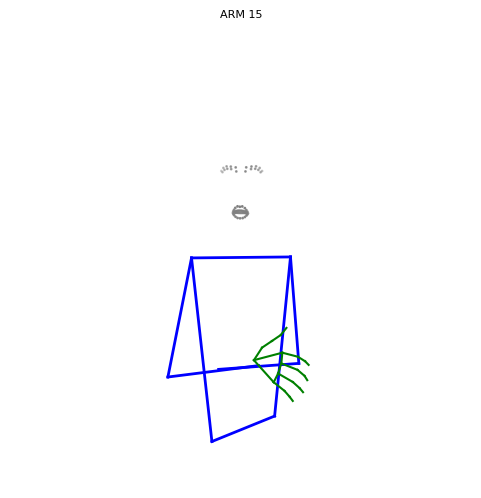

In [1]:
import os
import re
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, writers
import matplotlib as mpl
import imageio_ffmpeg as ffmpeg
from pathlib import Path

# ==============================
# 1. CONFIGURATION
# ==============================
DATA_DIR = r"clean_dataset/ARM_v1"
OUTPUT_DIR = r"skeleton/ARM_v1"

# ==============================
# 2. CONNECTIONS
# ==============================
POSE_CONN = [(11, 12), (11, 13), (13, 15), (12, 14), (14, 16), (11, 23), (12, 24), (23, 24)]
HAND_CONN = [(0,1),(1,2),(2,3),(3,4),(0,5),(5,6),(6,7),(7,8),(5,9),(9,10),(10,11),(11,12),
             (9,13),(13,14),(14,15),(15,16),(13,17),(17,18),(18,19),(19,20),(0,17)]

# ==============================
# 3. GET ALL FILES (FIXED)
# ==============================
data_path = Path(DATA_DIR)
npy_files = list(data_path.rglob("*.npy"))

if not npy_files:
    print("❌ No .npy files found")
    exit()

# ==============================
# 4. PROCESS EACH FILE
# ==============================
for file_path_obj in npy_files:

    file_path = str(file_path_obj)

    # keep folder structure (optional but better)
    relative_path = file_path_obj.relative_to(DATA_DIR)
    output_path = Path(OUTPUT_DIR) / relative_path.with_suffix(".mp4")
    output_path.parent.mkdir(parents=True, exist_ok=True)

    try:
        data = np.load(file_path)
        print(f"🎬 Rendering: {file_path_obj.name} | Frames: {len(data)}")

        fig = plt.figure(figsize=(6, 6))
        ax = fig.add_subplot(111, projection='3d')

        def update(frame):
            ax.cla()
            current_frame = data[frame]

            pose = current_frame[:132].reshape(33, 4)
            face = current_frame[132:312].reshape(60, 3)
            lh   = current_frame[312:375].reshape(21, 3)
            rh   = current_frame[375:].reshape(21, 3)

            # POSE
            for s, e in POSE_CONN:
                if pose[s, 3] > 0.1 and pose[e, 3] > 0.1:
                    ax.plot([pose[s, 0], pose[e, 0]],
                            [pose[s, 1], pose[e, 1]],
                            [pose[s, 2], pose[e, 2]],
                            color='blue', linewidth=2)

            # HANDS
            for hand, color in [(lh, 'red'), (rh, 'green')]:
                if np.any(np.abs(hand) > 1e-6):
                    for s, e in HAND_CONN:
                        ax.plot([hand[s, 0], hand[e, 0]],
                                [hand[s, 1], hand[e, 1]],
                                [hand[s, 2], hand[e, 2]],
                                color=color, linewidth=1.5)

            # FACE
            if np.any(np.abs(face) > 1e-6):
                ax.scatter(face[:, 0], face[:, 1], face[:, 2], s=1, color='gray')

            ax.set_title(file_path_obj.stem, fontsize=8)
            ax.set_xlim([0, 1]); ax.set_ylim([0, 1]); ax.set_zlim([-1, 1])
            ax.view_init(elev=-90, azim=-90)
            ax.axis('off')

        ani = FuncAnimation(fig, update, frames=len(data), interval=50, blit=False)

        mpl.rcParams['animation.ffmpeg_path'] = ffmpeg.get_ffmpeg_exe()
        FFMpegWriter = writers['ffmpeg']
        writer = FFMpegWriter(fps=20, codec='libx264', extra_args=['-pix_fmt','yuv420p'])

        ani.save(str(output_path), writer=writer)
        plt.close(fig)

        print(f"✅ Saved: {output_path}")

    except Exception as e:
        print(f"❌ Error processing {file_path_obj.name}: {e}")
        plt.close('all')

🎬 Rendering: ARM 19.npy | Frames: 62
✅ Saved: skeleton\ARM_V2\ARM 19.mp4
🎬 Rendering: ARM 22.npy | Frames: 84
✅ Saved: skeleton\ARM_V2\ARM 22.mp4
🎬 Rendering: ARM 23.npy | Frames: 171
✅ Saved: skeleton\ARM_V2\ARM 23.mp4
🎬 Rendering: ARM 24.npy | Frames: 47


KeyboardInterrupt: 

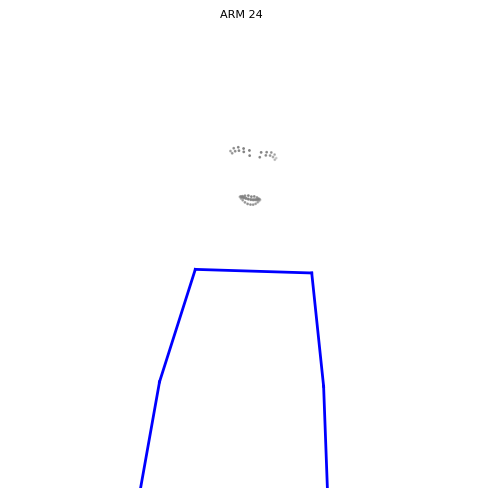

In [2]:
import os
import re
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, writers
import matplotlib as mpl
import imageio_ffmpeg as ffmpeg
from pathlib import Path

# ==============================
# 1. CONFIGURATION
# ==============================
DATA_DIR = r"clean_dataset/ARM_v2"
OUTPUT_DIR = r"skeleton/ARM_V2"

# ==============================
# 2. CONNECTIONS
# ==============================
POSE_CONN = [(11, 12), (11, 13), (13, 15), (12, 14), (14, 16), (11, 23), (12, 24), (23, 24)]
HAND_CONN = [(0,1),(1,2),(2,3),(3,4),(0,5),(5,6),(6,7),(7,8),(5,9),(9,10),(10,11),(11,12),
             (9,13),(13,14),(14,15),(15,16),(13,17),(17,18),(18,19),(19,20),(0,17)]

# ==============================
# 3. GET ALL FILES (FIXED)
# ==============================
data_path = Path(DATA_DIR)
npy_files = list(data_path.rglob("*.npy"))

if not npy_files:
    print("❌ No .npy files found")
    exit()

# ==============================
# 4. PROCESS EACH FILE
# ==============================
for file_path_obj in npy_files:

    file_path = str(file_path_obj)

    # keep folder structure (optional but better)
    relative_path = file_path_obj.relative_to(DATA_DIR)
    output_path = Path(OUTPUT_DIR) / relative_path.with_suffix(".mp4")
    output_path.parent.mkdir(parents=True, exist_ok=True)

    try:
        data = np.load(file_path)
        print(f"🎬 Rendering: {file_path_obj.name} | Frames: {len(data)}")

        fig = plt.figure(figsize=(6, 6))
        ax = fig.add_subplot(111, projection='3d')

        def update(frame):
            ax.cla()
            current_frame = data[frame]

            pose = current_frame[:132].reshape(33, 4)
            face = current_frame[132:312].reshape(60, 3)
            lh   = current_frame[312:375].reshape(21, 3)
            rh   = current_frame[375:].reshape(21, 3)

            # POSE
            for s, e in POSE_CONN:
                if pose[s, 3] > 0.1 and pose[e, 3] > 0.1:
                    ax.plot([pose[s, 0], pose[e, 0]],
                            [pose[s, 1], pose[e, 1]],
                            [pose[s, 2], pose[e, 2]],
                            color='blue', linewidth=2)

            # HANDS
            for hand, color in [(lh, 'red'), (rh, 'green')]:
                if np.any(np.abs(hand) > 1e-6):
                    for s, e in HAND_CONN:
                        ax.plot([hand[s, 0], hand[e, 0]],
                                [hand[s, 1], hand[e, 1]],
                                [hand[s, 2], hand[e, 2]],
                                color=color, linewidth=1.5)

            # FACE
            if np.any(np.abs(face) > 1e-6):
                ax.scatter(face[:, 0], face[:, 1], face[:, 2], s=1, color='gray')

            ax.set_title(file_path_obj.stem, fontsize=8)
            ax.set_xlim([0, 1]); ax.set_ylim([0, 1]); ax.set_zlim([-1, 1])
            ax.view_init(elev=-90, azim=-90)
            ax.axis('off')

        ani = FuncAnimation(fig, update, frames=len(data), interval=50, blit=False)

        mpl.rcParams['animation.ffmpeg_path'] = ffmpeg.get_ffmpeg_exe()
        FFMpegWriter = writers['ffmpeg']
        writer = FFMpegWriter(fps=20, codec='libx264', extra_args=['-pix_fmt','yuv420p'])

        ani.save(str(output_path), writer=writer)
        plt.close(fig)

        print(f"✅ Saved: {output_path}")

    except Exception as e:
        print(f"❌ Error processing {file_path_obj.name}: {e}")
        plt.close('all')

In [3]:
import os
import re
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, writers
import matplotlib as mpl
import imageio_ffmpeg as ffmpeg
from pathlib import Path

# ==============================
# 1. CONFIGURATION
# ==============================
DATA_DIR = r"clean_dataset/ARM_v3"
OUTPUT_DIR = r"skeleton/ARM_V3"

# ==============================
# 2. CONNECTIONS
# ==============================
POSE_CONN = [(11, 12), (11, 13), (13, 15), (12, 14), (14, 16), (11, 23), (12, 24), (23, 24)]
HAND_CONN = [(0,1),(1,2),(2,3),(3,4),(0,5),(5,6),(6,7),(7,8),(5,9),(9,10),(10,11),(11,12),
             (9,13),(13,14),(14,15),(15,16),(13,17),(17,18),(18,19),(19,20),(0,17)]

# ==============================
# 3. GET ALL FILES (FIXED)
# ==============================
data_path = Path(DATA_DIR)
npy_files = list(data_path.rglob("*.npy"))

if not npy_files:
    print("❌ No .npy files found")
    exit()

# ==============================
# 4. PROCESS EACH FILE
# ==============================
for file_path_obj in npy_files:

    file_path = str(file_path_obj)

    # keep folder structure (optional but better)
    relative_path = file_path_obj.relative_to(DATA_DIR)
    output_path = Path(OUTPUT_DIR) / relative_path.with_suffix(".mp4")
    output_path.parent.mkdir(parents=True, exist_ok=True)

    try:
        data = np.load(file_path)
        print(f"🎬 Rendering: {file_path_obj.name} | Frames: {len(data)}")

        fig = plt.figure(figsize=(6, 6))
        ax = fig.add_subplot(111, projection='3d')

        def update(frame):
            ax.cla()
            current_frame = data[frame]

            pose = current_frame[:132].reshape(33, 4)
            face = current_frame[132:312].reshape(60, 3)
            lh   = current_frame[312:375].reshape(21, 3)
            rh   = current_frame[375:].reshape(21, 3)

            # POSE
            for s, e in POSE_CONN:
                if pose[s, 3] > 0.1 and pose[e, 3] > 0.1:
                    ax.plot([pose[s, 0], pose[e, 0]],
                            [pose[s, 1], pose[e, 1]],
                            [pose[s, 2], pose[e, 2]],
                            color='blue', linewidth=2)

            # HANDS
            for hand, color in [(lh, 'red'), (rh, 'green')]:
                if np.any(np.abs(hand) > 1e-6):
                    for s, e in HAND_CONN:
                        ax.plot([hand[s, 0], hand[e, 0]],
                                [hand[s, 1], hand[e, 1]],
                                [hand[s, 2], hand[e, 2]],
                                color=color, linewidth=1.5)

            # FACE
            if np.any(np.abs(face) > 1e-6):
                ax.scatter(face[:, 0], face[:, 1], face[:, 2], s=1, color='gray')

            ax.set_title(file_path_obj.stem, fontsize=8)
            ax.set_xlim([0, 1]); ax.set_ylim([0, 1]); ax.set_zlim([-1, 1])
            ax.view_init(elev=-90, azim=-90)
            ax.axis('off')

        ani = FuncAnimation(fig, update, frames=len(data), interval=50, blit=False)

        mpl.rcParams['animation.ffmpeg_path'] = ffmpeg.get_ffmpeg_exe()
        FFMpegWriter = writers['ffmpeg']
        writer = FFMpegWriter(fps=20, codec='libx264', extra_args=['-pix_fmt','yuv420p'])

        ani.save(str(output_path), writer=writer)
        plt.close(fig)

        print(f"✅ Saved: {output_path}")

    except Exception as e:
        print(f"❌ Error processing {file_path_obj.name}: {e}")
        plt.close('all')

🎬 Rendering: ARM 12.npy | Frames: 70
✅ Saved: skeleton\ARM_V3\ARM 12.mp4
🎬 Rendering: ARM 13.npy | Frames: 74
✅ Saved: skeleton\ARM_V3\ARM 13.mp4
🎬 Rendering: ARM 14.npy | Frames: 68
✅ Saved: skeleton\ARM_V3\ARM 14.mp4
🎬 Rendering: ARM 16.npy | Frames: 62
✅ Saved: skeleton\ARM_V3\ARM 16.mp4
🎬 Rendering: ARM 17.npy | Frames: 55
✅ Saved: skeleton\ARM_V3\ARM 17.mp4
🎬 Rendering: ARM 21.npy | Frames: 156
✅ Saved: skeleton\ARM_V3\ARM 21.mp4
🎬 Rendering: ARM 29.npy | Frames: 51
✅ Saved: skeleton\ARM_V3\ARM 29.mp4
🎬 Rendering: ARM 35.npy | Frames: 95
✅ Saved: skeleton\ARM_V3\ARM 35.mp4
🎬 Rendering: ARM 36.npy | Frames: 123
✅ Saved: skeleton\ARM_V3\ARM 36.mp4
🎬 Rendering: ARM 38.npy | Frames: 66
✅ Saved: skeleton\ARM_V3\ARM 38.mp4
🎬 Rendering: ARM 46.npy | Frames: 132
✅ Saved: skeleton\ARM_V3\ARM 46.mp4
🎬 Rendering: ARM 48.npy | Frames: 68
✅ Saved: skeleton\ARM_V3\ARM 48.mp4
🎬 Rendering: ARM 5.npy | Frames: 49
✅ Saved: skeleton\ARM_V3\ARM 5.mp4
🎬 Rendering: ARM 54.npy | Frames: 100
✅ Saved: ske